# Lecture 10 — Normalization and Regularization

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

Careful initialisation keeps activations well-scaled *at the start* of training, and lecture 7
showed how fragile that is. This lecture asks two questions:

1. **Normalization** — instead of hoping the scale stays right, can a layer *force* it?
   Layer norm and batch norm, and the surprising way they differ.
2. **Regularization** — deep networks have more parameters than examples and can memorise their
   training set. What stops that? Weight decay and dropout.

Every layer here is built from the lecture 6 engine's ops, so its gradient is automatic — and then
checked against finite differences anyway.

## 0. Engine and building blocks

The same needle-style engine as lecture 9, plus a small module library.

In [1]:
import numpy as np

class Tensor:
    """A needle-style tensor: data plus the op and inputs that produced it."""

    def __init__(self, array, requires_grad=True):
        self._init(None, [], np.asarray(array, dtype=np.float64), requires_grad)

    def _init(self, op, inputs, cached, requires_grad):
        self.op, self.inputs = op, list(inputs)
        self.cached, self.requires_grad, self.grad = cached, requires_grad, None

    @classmethod
    def make_const(cls, array):
        """A leaf with no history - what detach() returns."""
        t = Tensor.__new__(Tensor)
        t._init(None, [], array, False)
        return t

    @staticmethod
    def make_from_op(op, inputs):
        out = op.compute(*[i.cached for i in inputs])
        if not any(i.requires_grad for i in inputs):
            return Tensor.make_const(out)        # nothing needs a gradient: no graph
        t = Tensor.__new__(Tensor)
        t._init(op, inputs, out, True)
        return t

    # .data is a detached view that SHARES memory; assigning to it updates in place
    @property
    def data(self):
        return Tensor.make_const(self.cached)
    @data.setter
    def data(self, value):
        self.cached = value.cached if isinstance(value, Tensor) else np.asarray(value)

    def detach(self):  return self.data
    def numpy(self):   return self.cached
    shape = property(lambda s: s.cached.shape)
    def __repr__(self):
        return f"Tensor({np.array2string(self.cached, precision=4)}, op={type(self.op).__name__ if self.op else None})"

    def __add__(s, o):  return EAdd()(s, o) if isinstance(o, Tensor) else AddS(o)(s)
    def __mul__(s, o):  return EMul()(s, o) if isinstance(o, Tensor) else MulS(o)(s)
    def __neg__(s):     return MulS(-1.0)(s)
    def __sub__(s, o):  return s + (-o)
    def __rsub__(s, o): return (-s) + o
    def __pow__(s, c):  return PowS(c)(s)
    def __truediv__(s, o):
        return s * (o ** -1.0) if isinstance(o, Tensor) else MulS(1.0 / o)(s)
    def __matmul__(s, o): return MatMul()(s, o)
    __radd__, __rmul__ = __add__, __mul__

    def backward(self):
        backprop(self, Tensor.make_const(np.ones_like(self.cached)))


class Op:
    def __call__(self, *ins):
        return Tensor.make_from_op(self, ins)
    def grads(self, g, node):
        r = self.gradient(g, node)
        return r if isinstance(r, tuple) else (r,)

class EAdd(Op):
    def compute(s, a, b): return a + b
    def gradient(s, g, n): return g, g
class AddS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a + s.c
    def gradient(s, g, n): return g
class EMul(Op):
    def compute(s, a, b): return a * b
    def gradient(s, g, n): return g * n.inputs[1], g * n.inputs[0]
class MulS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a * s.c
    def gradient(s, g, n): return g * s.c
class PowS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a ** s.c
    def gradient(s, g, n): return g * (n.inputs[0] ** (s.c - 1)) * s.c
class MatMul(Op):
    def compute(s, a, b): return a @ b
    def gradient(s, g, n):
        return g @ transpose(n.inputs[1]), transpose(n.inputs[0]) @ g
class Transpose(Op):
    def compute(s, a): return a.T
    def gradient(s, g, n): return transpose(g)
class Reshape(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return a.reshape(s.shape)
    def gradient(s, g, n): return reshape(g, n.inputs[0].shape)
class BroadcastTo(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return np.broadcast_to(a, s.shape).copy()
    def gradient(s, g, n):                        # broadcast forward = sum backward
        ins = n.inputs[0].shape
        pad = len(s.shape) - len(ins)
        axes = tuple(range(pad)) + tuple(pad + i for i, d in enumerate(ins)
                                         if d == 1 and s.shape[pad + i] != 1)
        return reshape(summation(g, axes) if axes else g, ins)
class Summation(Op):
    def __init__(s, axes=None):
        s.axes = (axes,) if isinstance(axes, int) else axes
    def compute(s, a): return a.sum(axis=s.axes)
    def gradient(s, g, n):
        ins = n.inputs[0].shape
        ax = range(len(ins)) if s.axes is None else s.axes
        keep = tuple(1 if i in ax else d for i, d in enumerate(ins))
        return broadcast_to(reshape(g, keep), ins)
class ReLUOp(Op):
    def compute(s, a): return np.maximum(0, a)
    def gradient(s, g, n):
        return g * Tensor.make_const((n.inputs[0].cached > 0) * 1.0)
class Exp(Op):
    def compute(s, a): return np.exp(a)
    def gradient(s, g, n): return g * exp(n.inputs[0])
class LogSumExp(Op):
    """Stable log-sum-exp over axis 1: subtract the row max first."""
    def compute(s, a):
        m = a.max(1, keepdims=True)
        return (np.log(np.exp(a - m).sum(1, keepdims=True)) + m)[:, 0]
    def gradient(s, g, n):
        z = n.inputs[0]
        sm = exp(z - broadcast_to(reshape(n, (z.shape[0], 1)), z.shape))
        return broadcast_to(reshape(g, (z.shape[0], 1)), z.shape) * sm

transpose    = lambda a: Transpose()(a)
reshape      = lambda a, s: Reshape(s)(a)
broadcast_to = lambda a, s: BroadcastTo(s)(a)
summation    = lambda a, axes=None: Summation(axes)(a)
relu         = lambda a: ReLUOp()(a)
exp          = lambda a: Exp()(a)
logsumexp    = lambda a: LogSumExp()(a)

def topo_sort(root):
    """Post-order DFS, iterative so that very deep graphs cannot overflow the stack."""
    order, seen, stack = [], set(), [(root, False)]
    while stack:
        node, done = stack.pop()
        if done:
            order.append(node)
            continue
        if id(node) in seen:
            continue
        seen.add(id(node))
        stack.append((node, True))
        for i in node.inputs:
            if id(i) not in seen:
                stack.append((i, False))
    return order

def backprop(out, seed):
    """Reverse-mode AD: walk reverse topological order, summing partial adjoints."""
    parts = {id(out): [seed]}
    for node in reversed(topo_sort(out)):
        if id(node) not in parts: continue
        g = parts[id(node)][0]
        for extra in parts[id(node)][1:]:
            g = g + extra
        node.grad = g
        if node.op is not None:
            for inp, p in zip(node.inputs, node.op.grads(g, node)):
                if inp.requires_grad:
                    parts.setdefault(id(inp), []).append(p)

def numeric_grad(f, param, eps=1e-6):
    """Two-sided finite differences of scalar f() w.r.t. every entry of param."""
    g = np.zeros_like(param.cached)
    for idx in np.ndindex(*param.cached.shape):
        old = param.cached[idx]
        param.cached[idx] = old + eps; a = float(f().cached)
        param.cached[idx] = old - eps; b = float(f().cached)
        param.cached[idx] = old
        g[idx] = (a - b) / (2 * eps)
    return g

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

def one_hot(y, k=10):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

print("engine and data ready:", X_train.shape, X_test.shape)

engine and data ready: (1347, 64) (450, 64)


In [2]:
class Parameter(Tensor):
    pass

class Module:
    training = True
    def parameters(self):
        out = []
        for v in self.__dict__.values():
            if isinstance(v, Parameter): out.append(v)
            elif isinstance(v, Module):  out += v.parameters()
            elif isinstance(v, (list, tuple)):
                for item in v:
                    if isinstance(item, Module): out += item.parameters()
        return out
    def children(self):
        kids = [v for v in self.__dict__.values() if isinstance(v, Module)]
        for v in self.__dict__.values():
            if isinstance(v, (list, tuple)):
                kids += [i for i in v if isinstance(i, Module)]
        return kids
    def train(self, mode=True):
        self.training = mode
        for c in self.children(): c.train(mode)
        return self
    def eval(self):
        return self.train(False)
    def __call__(self, *a):
        return self.forward(*a)

class Linear(Module):
    def __init__(self, n_in, n_out, rng, c=2.0, bias=True):
        self.W = Parameter(rng.normal(0, np.sqrt(c / n_in), (n_in, n_out)))   # variance c/n
        self.b = Parameter(np.zeros((1, n_out))) if bias else None
    def forward(self, x):
        out = x @ self.W
        if self.b is not None:
            out = out + broadcast_to(self.b, out.shape)
        return out

class ReLU(Module):
    def forward(self, x): return relu(x)

class Sequential(Module):
    def __init__(self, *mods): self.mods = list(mods)
    def forward(self, x):
        for m in self.mods: x = m(x)
        return x

def softmax_loss(logits, Y):
    B = logits.shape[0]
    return summation(logsumexp(logits) - summation(logits * Y, 1)) / B

print("modules ready")

modules ready


## 1. The problem, measured

Build a 50-layer ReLU network, width 128, initialise every weight with variance $c/n$ for
$c = 1, 2, 3$, push one batch of digits through, and measure two things at every layer: the size
of the **activations** on the way forward, and the size of the **weight gradients** on the way
back.

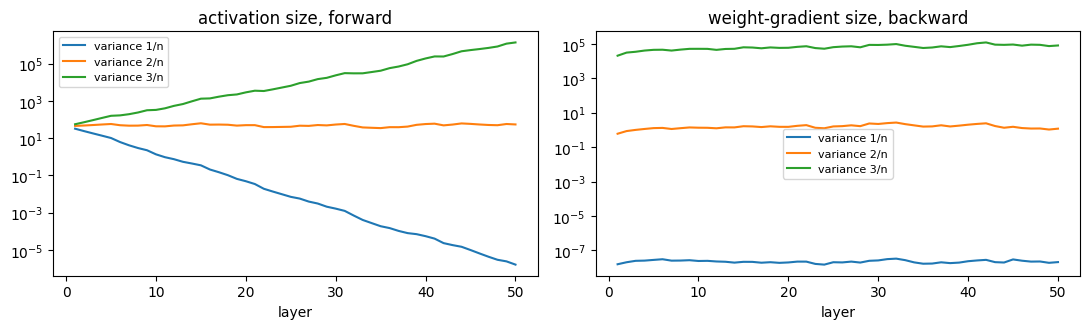

variance 1/n : activation at layer 50  1.61e-06   typical gradient  2.21e-08
variance 2/n : activation at layer 50  5.42e+01   typical gradient  1.51e+00
variance 3/n : activation at layer 50  1.37e+06   typical gradient  6.33e+04


In [3]:
def deep_stats(c, depth=50, width=128, norm=None, seed=0):
    rng = np.random.default_rng(seed)
    layers, dims = [], [64] + [width] * depth
    for i in range(depth):
        layers.append(Linear(dims[i], dims[i + 1], rng, c=c, bias=False))
    head = Linear(width, 10, rng, c=1.0, bias=False)

    X = Tensor(X_train[:64], requires_grad=False)
    Y = Tensor.make_const(one_hot(y_train[:64]))
    z, act = X, []
    for lin in layers:
        z = relu(lin(z))
        if norm is not None:
            z = norm(z)
        act.append(np.linalg.norm(z.cached))
    loss = softmax_loss(head(z), Y)
    loss.backward()
    grad = [np.linalg.norm(l.W.grad.cached) for l in layers]
    return np.array(act), np.array(grad)

stats = {c: deep_stats(c) for c in (1.0, 2.0, 3.0)}

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for c, (a, g) in stats.items():
    ax[0].semilogy(range(1, 51), a, label=f"variance {int(c)}/n")
    ax[1].semilogy(range(1, 51), g, label=f"variance {int(c)}/n")
ax[0].set_title("activation size, forward"); ax[1].set_title("weight-gradient size, backward")
for a_ in ax: a_.set_xlabel("layer"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

for c, (a, g) in stats.items():
    print(f"variance {int(c)}/n : activation at layer 50 {a[-1]:9.2e}   typical gradient {np.median(g):9.2e}")

The forward picture is lecture 7 again: $1/n$ collapses, $3/n$ explodes, only $2/n$ holds steady.
The backward picture is the part lecture 10 adds: the *level* of the weight gradients moves with the
initialisation too — a typical gradient is around $10^{-8}$ at $1/n$, around $1$ at $2/n$, and
around $10^{4}$ at $3/n$. Too small and training stalls; too large and it diverges.

The lecture's response is not "initialise more carefully". It is: a layer can be *any*
differentiable function, so add one that forces the scale back to normal.

## 2. Layer normalisation

Standardise each example's activation vector: subtract its mean, divide by its standard deviation.

$$z_{i+1} = \frac{\hat z_{i+1} - \mathbb{E}[\hat z_{i+1}]}{\sqrt{\mathrm{Var}[\hat z_{i+1}] + \epsilon}}$$

The mean and variance are taken over the entries of **one example** — one row of the batch matrix.
The small $\epsilon$ exists because a ReLU can zero out a whole vector, and dividing by a variance
of zero would be fatal.

In [4]:
class LayerNorm1d(Module):
    """Normalise each ROW (each example) to mean 0, variance 1."""
    def __init__(self, eps=1e-5):
        self.eps = eps
    def forward(self, x):
        B, d = x.shape
        mean = reshape(summation(x, 1) / d, (B, 1))                  # one mean per example
        xc   = x - broadcast_to(mean, (B, d))
        var  = reshape(summation(xc * xc, 1) / d, (B, 1))            # one variance per example
        return xc * broadcast_to((var + self.eps) ** -0.5, (B, d))

# built entirely from ops, so the gradient is automatic - but check it anyway
rng = np.random.default_rng(1)
W = Parameter(rng.normal(size=(5, 4)))
Xs = Tensor(rng.normal(size=(3, 5)), requires_grad=False)
Ys = Tensor.make_const(one_hot(np.array([0, 2, 3]), 4))
ln = LayerNorm1d()
f = lambda: softmax_loss(ln(Xs @ W) * 2.0, Ys)
f().backward()
print("layer norm gradient, max |autodiff - numeric| =", np.abs(W.grad.cached - numeric_grad(f, W)).max())

out = ln(Tensor(rng.normal(3.0, 5.0, size=(4, 6))))
print("row means     :", np.round(out.cached.mean(1), 6))
print("row variances :", np.round(out.cached.var(1), 4))

layer norm gradient, max |autodiff - numeric| = 6.471490010540037e-10
row means     : [0. 0. 0. 0.]
row variances : [1. 1. 1. 1.]


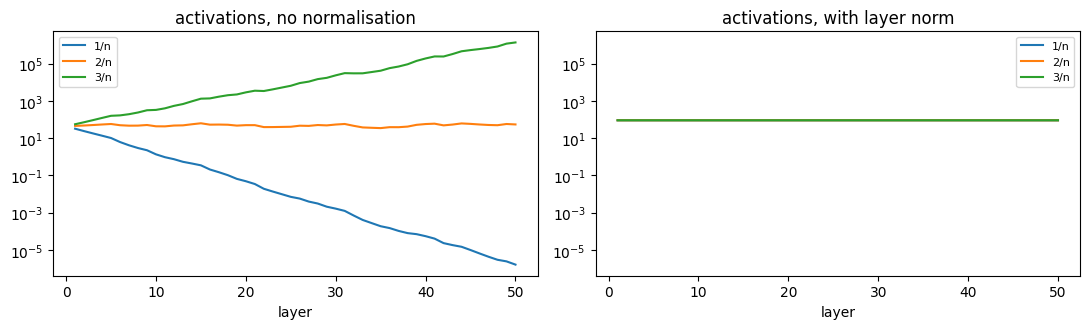

1/n with layer norm: activation at layer 50 = 90.508   typical gradient = 2.62e+02
2/n with layer norm: activation at layer 50 = 90.509   typical gradient = 1.86e+02
3/n with layer norm: activation at layer 50 = 90.509   typical gradient = 1.52e+02


In [5]:
stats_ln = {c: deep_stats(c, norm=LayerNorm1d()) for c in (1.0, 2.0, 3.0)}

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for c in (1.0, 2.0, 3.0):
    ax[0].semilogy(range(1, 51), stats[c][0], label=f"{int(c)}/n")
    ax[1].semilogy(range(1, 51), stats_ln[c][0], label=f"{int(c)}/n")
ax[0].set_title("activations, no normalisation"); ax[1].set_title("activations, with layer norm")
ax[1].set_ylim(ax[0].get_ylim())
for a_ in ax: a_.set_xlabel("layer"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

for c in (1.0, 2.0, 3.0):
    print(f"{int(c)}/n with layer norm: activation at layer 50 = {stats_ln[c][0][-1]:.3f}"
          f"   typical gradient = {np.median(stats_ln[c][1]):.2e}")

All three initialisations now give activations of *exactly* the same size at every layer — about
$90.5$, which is $\sqrt{64 \times 128}$: 64 examples, each a 128-dimensional vector with mean 0 and
variance 1. Their gradients also land at the same level, within a factor of two of each other
instead of twelve orders of magnitude apart. The initial variance has stopped mattering.

### The cost: layer norm erases size

Take three examples whose activations differ only in scale.

In [6]:
Z = Tensor(np.array([[1., 3.], [2., 6.], [3., 9.]]))
print("before:\n", Z.cached)
print("\nafter layer norm (rows):\n", np.round(LayerNorm1d(eps=0)(Z).cached, 3))

before:
 [[1. 3.]
 [2. 6.]
 [3. 9.]]

after layer norm (rows):
 [[-1.  1.]
 [-1.  1.]
 [-1.  1.]]


All three examples become the identical vector $[-1, 1]$. Whatever information lived in how *large*
an example's activations were — and that could be exactly what separates a 1 from a 0 — is gone.
This is one reason plain fully connected networks are often *harder* to train to low loss with
layer norm, even though transformers depend on it.

## 3. Batch normalisation

Same arithmetic, other axis. Instead of normalising each **row** (example), normalise each
**column** (feature) across the batch — like standardising each feature of a dataset in classical
machine learning, but at every layer and every minibatch.

In [7]:
class BatchNorm1d(Module):
    """Normalise each COLUMN over the batch. Running averages are used at test time."""
    def __init__(self, dim, beta=0.9, eps=1e-5):
        self.beta, self.eps = beta, eps
        self.running_mean = np.zeros(dim)
        self.running_var  = np.ones(dim)
    def forward(self, x):
        B, d = x.shape
        if self.training:
            mean = reshape(summation(x, 0) / B, (1, d))              # one mean per feature
            xc   = x - broadcast_to(mean, (B, d))
            var  = reshape(summation(xc * xc, 0) / B, (1, d))
            # exponential moving averages - the same idea as momentum
            self.running_mean = self.beta * self.running_mean + (1 - self.beta) * mean.cached[0]
            self.running_var  = self.beta * self.running_var  + (1 - self.beta) * var.cached[0]
            return xc * broadcast_to((var + self.eps) ** -0.5, (B, d))
        mean = Tensor.make_const(self.running_mean.reshape(1, d))
        var  = Tensor.make_const(self.running_var.reshape(1, d))
        return (x - broadcast_to(mean, (B, d))) * broadcast_to((var + self.eps) ** -0.5, (B, d))

print("after batch norm (columns):\n",
      np.round(BatchNorm1d(2, eps=0)(Z).cached, 3))

bn = BatchNorm1d(4)
f = lambda: softmax_loss(bn(Xs @ W) * 2.0, Ys)
f().backward()
print("\nbatch norm gradient, max |autodiff - numeric| =",
      np.abs(W.grad.cached - numeric_grad(f, W)).max())

after batch norm (columns):
 [[-1.225 -1.225]
 [ 0.     0.   ]
 [ 1.225  1.225]]

batch norm gradient, max |autodiff - numeric| = 4.804235897992726e-10


With batch norm the three examples stay distinct — $-1.22$, $0$, $1.22$ — because each is measured
relative to the others. The size difference survives.

### The strange part: your output depends on your neighbours

Because the column mean comes from the whole batch, one example's output depends on which other
examples were in the batch with it. Feed the **same** example in two different batches:

In [8]:
rng = np.random.default_rng(3)
target = X_train[:1]                                      # the example we care about
batch_a = np.vstack([target, X_train[1:32]])
batch_b = np.vstack([target, X_train[500:531]])

lin = Linear(64, 8, np.random.default_rng(0))
bn  = BatchNorm1d(8)

bn.train()
out_a = bn(lin(Tensor(batch_a, requires_grad=False))).cached[0]
out_b = bn(lin(Tensor(batch_b, requires_grad=False))).cached[0]
print("training mode - same example, different batch-mates:")
print("  batch A:", np.round(out_a[:4], 3))
print("  batch B:", np.round(out_b[:4], 3))

bn.eval()
out_a = bn(lin(Tensor(batch_a, requires_grad=False))).cached[0]
out_b = bn(lin(Tensor(batch_b, requires_grad=False))).cached[0]
print("\neval mode (running averages):")
print("  batch A:", np.round(out_a[:4], 3))
print("  batch B:", np.round(out_b[:4], 3))

training mode - same example, different batch-mates:
  batch A: [-0.899  1.899  1.123 -0.885]
  batch B: [-1.087  1.844  1.095 -1.441]

eval mode (running averages):
  batch A: [-0.14   1.817 -0.369 -0.064]
  batch B: [-0.14   1.817 -0.369 -0.064]


In training mode the same input gives different outputs depending on its batch-mates. In eval mode,
using the stored running averages, it gives the same answer every time — which is why batch norm
switches behaviour at test time.

### The classic bug: evaluating in training mode

The running averages update on *every* forward pass in training mode — even one where no gradient
step is taken. Forget to call `eval()` before evaluating, and evaluation itself changes the model.

In [9]:
bn = BatchNorm1d(8); bn.train()
_ = bn(lin(Tensor(X_train[:64], requires_grad=False)))     # one "training" pass
before = bn.running_mean.copy()

for i in range(5):                                         # "evaluation", but still in train mode
    _ = bn(lin(Tensor(X_test[i*50:(i+1)*50], requires_grad=False)))
print("running mean changed during 'evaluation':", not np.allclose(before, bn.running_mean))
print("max change:", np.abs(bn.running_mean - before).max())

bn.eval(); before = bn.running_mean.copy()
for i in range(5):
    _ = bn(lin(Tensor(X_test[i*50:(i+1)*50], requires_grad=False)))
print("\nafter calling eval(), running mean changed:", not np.allclose(before, bn.running_mean))

running mean changed during 'evaluation': True
max change: 0.4262650766318836

after calling eval(), running mean changed: False


## 4. Does normalisation rescue training?

The real test: train 10-layer networks with each initialisation, with and without normalisation,
and see which ones learn.

In [10]:
def build_deep(c, norm, depth=10, width=64, seed=0):
    rng = np.random.default_rng(seed)
    mods, d_in = [], 64
    for _ in range(depth):
        mods += [Linear(d_in, width, rng, c=c), ReLU()]
        if norm == "layer": mods.append(LayerNorm1d())
        if norm == "batch": mods.append(BatchNorm1d(width))
        d_in = width
    mods.append(Linear(width, 10, rng, c=1.0))
    return Sequential(*mods)

def fit(model, epochs=8, lr=0.05, beta=0.9, B=64, seed=0, wd=0.0):
    rng = np.random.default_rng(seed)
    params = model.parameters()
    u = [np.zeros_like(p.cached) for p in params]
    for _ in range(epochs):
        model.train()
        order = rng.permutation(len(X_train))
        for i in range(0, len(order), B):
            idx = order[i:i + B]
            for p in params: p.grad = None
            loss = softmax_loss(model(Tensor(X_train[idx], requires_grad=False)),
                                Tensor.make_const(one_hot(y_train[idx])))
            if not np.isfinite(loss.cached):
                return float("nan")
            loss.backward()
            for j, p in enumerate(params):
                g = p.grad.cached + wd * p.cached
                u[j] = beta * u[j] + (1 - beta) * g
                p.data = p.data - Tensor.make_const(u[j]) * lr
    model.eval()
    logits = model(Tensor(X_test, requires_grad=False)).cached
    return float((logits.argmax(1) != y_test).mean())

print(f"{'initialisation':<16}{'no norm':>10}{'layer norm':>13}{'batch norm':>13}")
print("-" * 52)
for c in (1.0, 2.0, 3.0):
    row = [fit(build_deep(c, n)) for n in (None, "layer", "batch")]
    cells = ["diverged" if np.isnan(r) else f"{r:.3f}" for r in row]
    print(f"{int(c)}/n{'':<13}{cells[0]:>10}{cells[1]:>13}{cells[2]:>13}")

initialisation     no norm   layer norm   batch norm
----------------------------------------------------


1/n                  0.627        0.058        0.296


2/n                  0.109        0.071        0.560


3/n                  0.102        0.053        0.398


Read the **layer norm** column first. Without normalisation the $1/n$ network barely learns, and
the three initialisations end far apart. With layer norm all three reach roughly the same low error
— the layer has taken over the job careful initialisation was doing.

The **batch norm** column is worse, and it is worth being honest about why rather than guessing. My
first suspicion was the train/test switch: maybe the running averages were stale. That is testable —
evaluate the same trained models using the test set's own batch statistics instead:

In [11]:
print(f"{'initialisation':<16}{'running-average eval':>22}{'batch-statistics eval':>24}")
print("-" * 62)
for c in (1.0, 2.0, 3.0):
    m = build_deep(c, "batch")
    err_running = fit(m)
    m.train()                                    # use the test set's own batch statistics
    logits = m(Tensor(X_test, requires_grad=False)).cached
    err_batch = float((logits.argmax(1) != y_test).mean())
    print(f"{int(c)}/n{'':<13}{err_running:>22.3f}{err_batch:>24.3f}")

initialisation    running-average eval   batch-statistics eval
--------------------------------------------------------------


1/n                              0.296                   0.287


2/n                              0.560                   0.520


3/n                              0.398                   0.380


The error barely changes, so the running averages are **not** the problem: these batch-norm
networks are simply undertrained in this setup. This implementation also omits the learnable scale
and shift that real batch-norm layers add after normalising, and the learning rate was tuned with the
un-normalised network in mind. The lesson is narrower than "batch norm is bad" — it is that a
normalisation layer is not a free win, and it interacts with every other choice.

## 5. Regularisation: when the network memorises

Deep networks usually have more parameters than training examples, so they can fit the training set
perfectly. To make that visible, train a wide network on only **150** examples and watch the gap
between training and test error.

In [12]:
rng_small = np.random.default_rng(0)
small = rng_small.choice(len(X_train), 150, replace=False)
Xs_tr, ys_tr = X_train[small], y_train[small]

def build_wide(dropout=0.0, seed=0):
    rng = np.random.default_rng(seed)
    mods = [Linear(64, 256, rng), ReLU()]
    if dropout: mods.append(Dropout(dropout, seed))
    mods += [Linear(256, 256, rng), ReLU()]
    if dropout: mods.append(Dropout(dropout, seed + 1))
    mods.append(Linear(256, 10, rng, c=1.0))
    return Sequential(*mods)

class Dropout(Module):
    """Zero each activation with probability p, rescale the rest by 1/(1-p). Off at test time."""
    def __init__(self, p=0.5, seed=0):
        self.p, self.rng = p, np.random.default_rng(seed)
    def forward(self, x):
        if not self.training or self.p == 0:
            return x
        mask = (self.rng.random(x.shape) > self.p) / (1 - self.p)
        return x * Tensor.make_const(mask)

def fit_small(model, epochs=300, lr=0.05, B=50, wd=0.0, seed=0):
    rng = np.random.default_rng(seed)
    params = model.parameters()
    u = [np.zeros_like(p.cached) for p in params]
    for _ in range(epochs):
        model.train()
        order = rng.permutation(len(Xs_tr))
        for i in range(0, len(order), B):
            idx = order[i:i + B]
            for p in params: p.grad = None
            softmax_loss(model(Tensor(Xs_tr[idx], requires_grad=False)),
                         Tensor.make_const(one_hot(ys_tr[idx]))).backward()
            for j, p in enumerate(params):
                g = p.grad.cached + wd * p.cached             # weight decay: add lambda * w
                u[j] = 0.9 * u[j] + 0.1 * g
                p.data = p.data - Tensor.make_const(u[j]) * lr
    model.eval()
    err = lambda X, y: float((model(Tensor(X, requires_grad=False)).cached.argmax(1) != y).mean())
    wnorm = np.sqrt(sum((p.cached ** 2).sum() for p in params))
    return err(Xs_tr, ys_tr), err(X_test, y_test), wnorm

print(f"{'configuration':<26}{'train err':>11}{'test err':>11}{'weight norm':>13}")
print("-" * 61)
for name, model, wd in [("no regularisation",   build_wide(),            0.0),
                        ("weight decay 1e-2",   build_wide(),            1e-2),
                        ("dropout p = 0.5",     build_wide(dropout=0.5), 0.0)]:
    tr, te, wn = fit_small(model, wd=wd)
    print(f"{name:<26}{tr:>11.3f}{te:>11.3f}{wn:>13.2f}")

configuration               train err   test err  weight norm
-------------------------------------------------------------


no regularisation               0.000      0.049        32.96


weight decay 1e-2               0.000      0.053        21.79


dropout p = 0.5                 0.000      0.058        33.00


With only 150 examples every network reaches zero training error — it has memorised them. Weight
decay does exactly what it promises mechanically: the total weight norm falls by about a third. But
**neither regulariser improved test error here**; both came out slightly worse.

That is not a failed experiment — it is the lecture's own point about *implicit* regularisation. The
unregularised network already generalises well (about 5% test error from 150 examples) despite
having ~85,000 parameters, because SGD from a sensible initialisation only explores a small
neighbourhood of weights. Explicit regularisers help when that implicit restriction is not enough;
on small, clean data like this, it was.

## 6. Weight decay, precisely

Adding $\tfrac{\lambda}{2}\lVert W\rVert^2$ to the loss adds $\lambda W$ to the gradient, and
gradient descent becomes

$$W \leftarrow (1 - \alpha\lambda)\,W - \alpha\nabla\ell$$

— a shrink before every step. The shrink looks negligible and is not:

In [13]:
alpha, lam = 0.1, 0.01
factor = 1 - alpha * lam
for steps in (1, 100, 1000, 5000):
    print(f"after {steps:>5} steps with no gradient, a weight keeps {factor**steps:7.2%} of its size")

after     1 steps with no gradient, a weight keeps  99.90% of its size
after   100 steps with no gradient, a weight keeps  90.48% of its size
after  1000 steps with no gradient, a weight keeps  36.77% of its size
after  5000 steps with no gradient, a weight keeps   0.67% of its size


### Weight decay with Adam

The lecture's practical warning: to add weight decay to momentum or Adam, **do not invent a special
rule** — add $\lambda W$ to the gradient and pass the combined gradient through the optimizer as
usual. Done that way it is exactly L2 regularisation. Shrinking the weights directly instead gives a
*different* algorithm (this is what "AdamW" does, deliberately). Checking both claims:

In [14]:
def adam_run(grad_fn, steps=50, lr=0.05, lam=0.1, mode="loss"):
    w = np.array([2.0, -3.0])
    u = v = np.zeros(2)
    for t in range(1, steps + 1):
        g = grad_fn(w)
        if mode in ("loss", "grad"):      # L2 in the loss, or lambda*w added to the gradient
            g = g + lam * w               # (the two are the same computation)
        u = 0.9 * u + 0.1 * g
        v = 0.999 * v + 0.001 * g**2
        step = lr * (u / (1 - 0.9**t)) / (np.sqrt(v / (1 - 0.999**t)) + 1e-8)
        if mode == "decoupled":           # shrink the weights directly, outside Adam
            w = w * (1 - lr * lam)
        w = w - step
    return w

grad_fn = lambda w: np.array([2 * (w[0] - 1), 4 * (w[1] + 1)])   # a simple quadratic
print("Adam, L2 term in the loss       :", np.round(adam_run(grad_fn, mode="loss"), 5))
print("Adam, lambda*w added to gradient:", np.round(adam_run(grad_fn, mode="grad"), 5))
print("Adam, weights shrunk directly   :", np.round(adam_run(grad_fn, mode="decoupled"), 5))

Adam, L2 term in the loss       : [ 0.89913 -1.10459]
Adam, lambda*w added to gradient: [ 0.89913 -1.10459]
Adam, weights shrunk directly   : [ 0.95287 -0.90498]


The first two are identical. The third ends somewhere else, because Adam rescales the gradient
coordinate by coordinate: a penalty that goes *through* Adam gets rescaled with it, while a direct
shrink does not. Neither is wrong, but they are different algorithms, and the lecture's point is to
know which one you are running.

## 7. Dropout

During training each activation is zeroed with probability $p$ and the survivors are divided by
$1-p$. That rescaling keeps every activation's **expected value** unchanged:

In [15]:
drop = Dropout(p=0.5, seed=0)
a = Tensor(np.array([[2.0, 4.0, 6.0, 8.0]]))
print("one draw        :", drop(a).cached[0])
print("another draw    :", drop(a).cached[0])

samples = np.array([drop(a).cached[0] for _ in range(100_000)])
print("average of 100k :", np.round(samples.mean(0), 3), "  <- matches the input")

drop.eval()
print("eval mode       :", drop(a).cached[0], "  <- dropout switched off")

one draw        : [4. 0. 0. 0.]
another draw    : [ 4.  8. 12. 16.]


average of 100k : [2.005 3.989 5.965 8.003]   <- matches the input
eval mode       : [2. 4. 6. 8.]   <- dropout switched off


### Dropout is stochastic approximation, moved inside the network

The usual explanation — the network learns to cope with missing activations — never quite made sense
to Kolter, since nothing is missing at test time. His framing: SGD replaces a sum over *all
examples* with a random minibatch. Dropout replaces the sum inside each neuron,
$\sum_j W_{jk} z_j$, with a random subset of its terms, rescaled. Both are unbiased estimates of the
full sum, and both inject the same kind of regularising noise.

In [16]:
rng = np.random.default_rng(0)
z = rng.normal(size=256)                  # activations feeding one neuron
w = rng.normal(size=256)                  # that neuron's weights
exact = float(w @ z)

for p in (0.1, 0.5, 0.9):
    est = [(w * z * (rng.random(256) > p) / (1 - p)).sum() for _ in range(20_000)]
    print(f"p = {p}: exact {exact:7.3f}   mean of estimates {np.mean(est):7.3f}"
          f"   spread (std) {np.std(est):6.3f}")

p = 0.1: exact  10.364   mean of estimates  10.390   spread (std)  5.646


p = 0.5: exact  10.364   mean of estimates  10.315   spread (std) 16.884


p = 0.9: exact  10.364   mean of estimates  10.417   spread (std) 50.838


The average matches the exact sum at every $p$ — unbiased, like a minibatch gradient — while the
spread grows as more terms are dropped, exactly as a smaller minibatch gives a noisier gradient.

## Summary

- The *level* of the gradients is set by the initial variance — around $10^{-8}$, $1$ and $10^{4}$
  for $1/n$, $2/n$, $3/n$. Too small stalls training; too large diverges.
- **Layer norm** standardises each example (row). All three initialisations give identical
  activation sizes at every layer — but three examples differing only in scale collapse to the same
  vector $[-1, 1]$.
- **Batch norm** standardises each feature (column) across the batch, keeping examples distinct.
  It makes an example's output depend on its batch-mates, so test time uses running averages — and
  evaluating without `eval()` silently changes them.
- On 150 examples the network generalised well with no explicit regulariser, and weight decay and
  dropout did not improve it — implicit regularisation from SGD and initialisation was enough.
- **Weight decay** is L2 regularisation: $W \leftarrow (1-\alpha\lambda)W - \alpha\nabla\ell$. With
  Adam, adding $\lambda W$ to the gradient equals L2 in the loss; shrinking weights directly is a
  different algorithm.
- **Dropout** keeps each activation's expected value, switches off at test time, and is best read as
  an unbiased stochastic estimate of each neuron's sum — SGD's idea, one level down.